---

## 🧪 Regresión Lineal: Mínimos Cuadrados y Máxima Verosimilitud

**Autor:** Pastor E. Pérez Estigarribia  
**Correo:** peperez.estigarribia@pol.una.py  
**Fecha:** 2022-11-15


---

## 🎯 Objetivos del Práctico

### Objetivo General
- Aplicar técnicas de estimación de parámetros mediante mínimos cuadrados y máxima verosimilitud en modelos de regresión lineal, evaluando su ajuste y complejidad mediante el criterio de información de Akaike (AIC).

### Objetivos Específicos
- 📊 Explorar y visualizar datos multivariados para identificar patrones temporales y diferencias entre países.
- 🧮 Implementar modelos de regresión lineal simple y múltiple utilizando mínimos cuadrados (OLS) y máxima verosimilitud (MLE).
- 🔍 Comparar modelos con y sin interacción entre variables explicativas, interpretando sus coeficientes y significancia.
- 📈 Evaluar el ajuste de los modelos mediante métricas como R², AIC y gráficos de predicción.
- 🧪 Simular escenarios de estimación por MLE para validar la robustez de los parámetros estimados.
- 🧰 Integrar herramientas estadísticas y visuales en Python para reproducir el análisis
---



### 🔗 Recursos interactivos

In [ ]:
import webbrowser

urls = [
    "https://phet.colorado.edu/sims/html/least-squares-regression/latest/least-squares-regression_en.html",
    "https://phet.colorado.edu/sims/html/curve-fitting/latest/curve-fitting_en.html",
    "https://argoshare.is.ed.ac.uk/simple_regression/",
    "https://argoshare.is.ed.ac.uk/healthyr_book/regression.html",
    "https://argoshare.is.ed.ac.uk/simple_regression_diagnostics/",
    "https://argoshare.is.ed.ac.uk/multi_regression/",
    "https://en.wikipedia.org/wiki/Akaike_information_criterion"
]

for url in urls:
    webbrowser.open(url)

### 📦 Cargar datos y librerías

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm

In [ ]:
!pip install gapminder

from gapminder import gapminder
gapminder.head()

gapdata = gapminder.copy()

### 🔍 Exploración inicial

In [ ]:
print(gapdata.info())
print(gapdata.describe())
print(gapdata.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 80.0+ KB
None
             year      lifeExp           pop      gdpPercap
count  1704.00000  1704.000000  1.704000e+03    1704.000000
mean   1979.50000    59.474439  2.960121e+07    7215.327081
std      17.26533    12.917107  1.061579e+08    9857.454543
min    1952.00000    23.599000  6.001100e+04     241.165876
25%    1965.75000    48.198000  2.793664e+06    1202.060309
50%    1979.50000    60.712500  7.023596e+06    3531.846988
75%    1993.25000    70.845500  1.958522e+07    9325.462346
max    2007.00000    82.60

### 📊 Visualización por país europeo

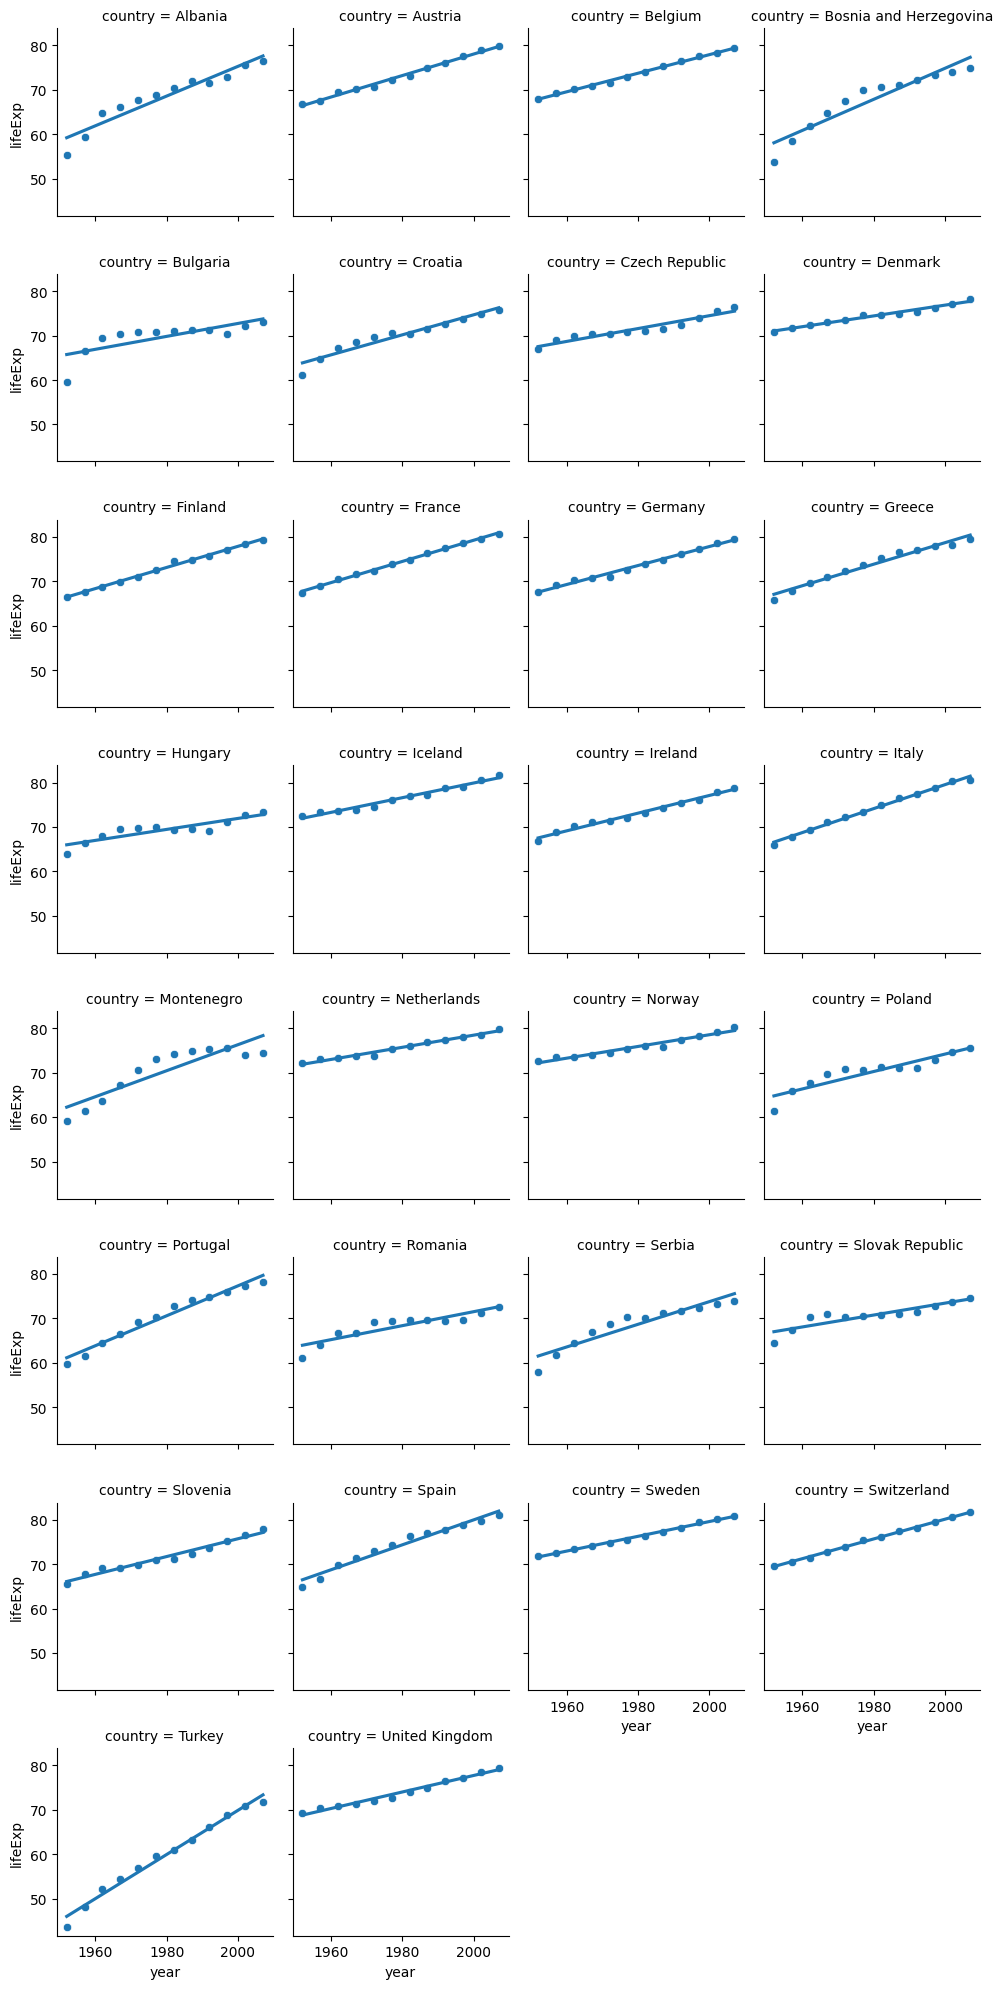

In [ ]:
europa = gapdata[gapdata['continent'] == 'Europe']
g = sns.FacetGrid(europa, col="country", col_wrap=4, height=2.5)
g.map_dataframe(sns.scatterplot, x="year", y="lifeExp")
g.map_dataframe(sns.regplot, x="year", y="lifeExp", scatter=False, ci=None)
plt.show()

### 📈 Regresión lineal simple

In [ ]:
uk = gapdata[gapdata['country'] == 'United Kingdom']
turkey = gapdata[gapdata['country'] == 'Turkey']

fit_uk = smf.ols('lifeExp ~ year', data=uk).fit()
fit_turkey = smf.ols('lifeExp ~ year', data=turkey).fit()

print(fit_uk.summary())
print(fit_turkey.summary())

                            OLS Regression Results                            
Dep. Variable:                lifeExp   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                     632.5
Date:                Tue, 11 Nov 2025   Prob (F-statistic):           2.26e-10
Time:                        02:17:01   Log-Likelihood:                -6.1392
No. Observations:                  12   AIC:                             16.28
Df Residuals:                      10   BIC:                             17.25
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -294.1966     14.638    -20.099      0.0


### 🔀 Modelos multivariados

In [ ]:
gapdata['year_from1952'] = gapdata['year'] - 1952
uk_turkey = gapdata[gapdata['country'].isin(['Turkey', 'United Kingdom'])]

fit1 = smf.ols('lifeExp ~ year_from1952', data=uk_turkey).fit()
fit2 = smf.ols('lifeExp ~ year_from1952 + country', data=uk_turkey).fit()
fit3 = smf.ols('lifeExp ~ year_from1952 * country', data=uk_turkey).fit()

/tmp/ipython-input-617879870.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uk_turkey['resid1'] = fit1.resid
/tmp/ipython-input-617879870.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uk_turkey['resid2'] = fit2.resid
/tmp/ipython-input-617879870.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexi

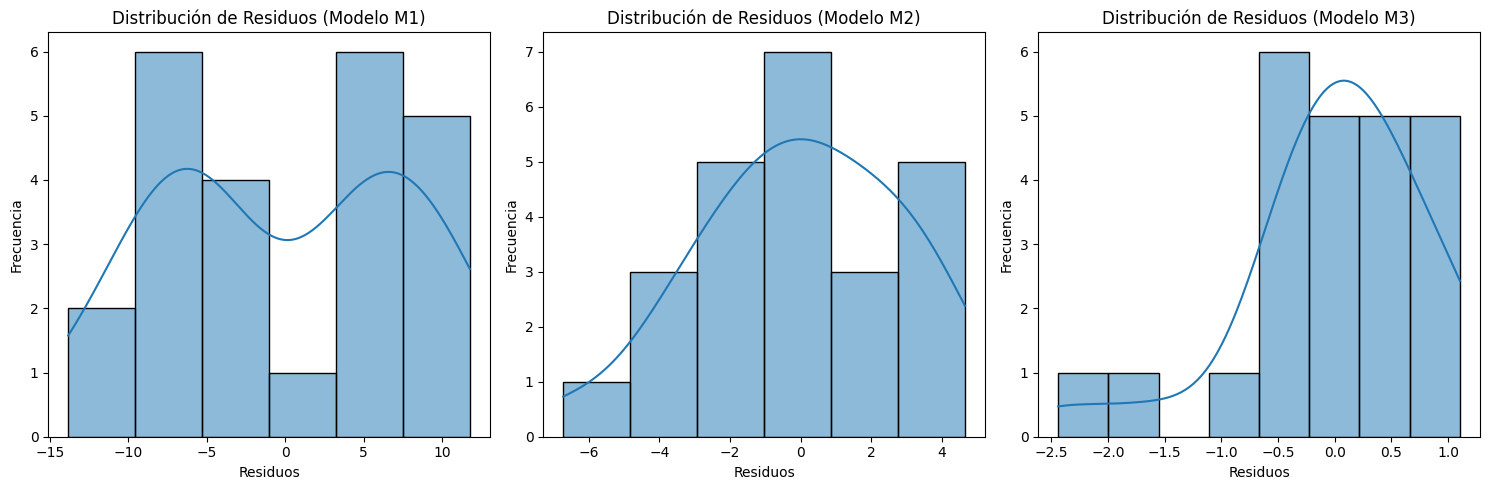

In [ ]:
# Calcular residuos para cada modelo
uk_turkey['resid1'] = fit1.resid
uk_turkey['resid2'] = fit2.resid
uk_turkey['resid3'] = fit3.resid

# Visualizar la distribución de residuos
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(uk_turkey['resid1'], kde=True)
plt.title('Distribución de Residuos (Modelo M1)')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')

plt.subplot(1, 3, 2)
sns.histplot(uk_turkey['resid2'], kde=True)
plt.title('Distribución de Residuos (Modelo M2)')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')

plt.subplot(1, 3, 3)
sns.histplot(uk_turkey['resid3'], kde=True)
plt.title('Distribución de Residuos (Modelo M3)')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### 📐 Visualización de predicciones

/tmp/ipython-input-3403113126.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uk_turkey['pred2'] = fit2.predict(uk_turkey)
/tmp/ipython-input-3403113126.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uk_turkey['pred3'] = fit3.predict(uk_turkey)


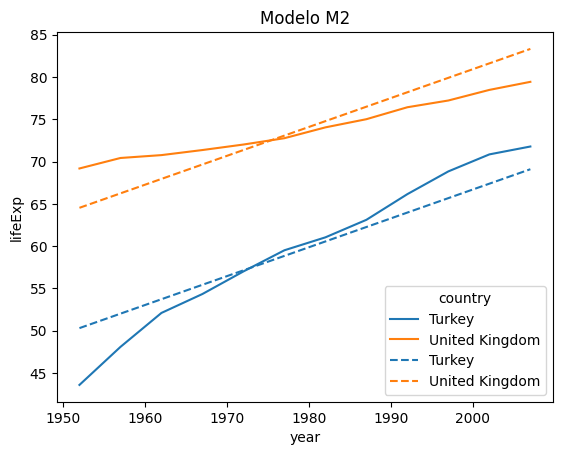

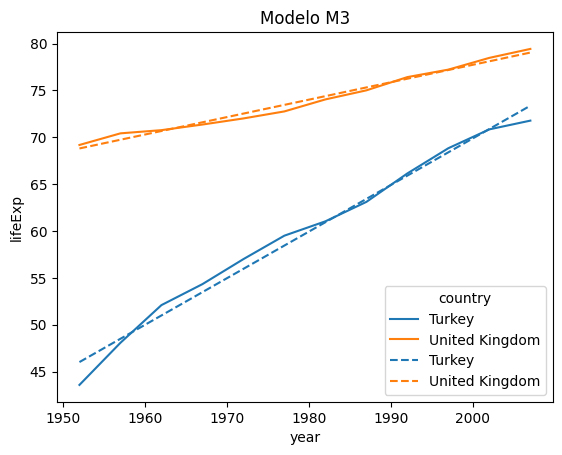

In [ ]:
uk_turkey['pred2'] = fit2.predict(uk_turkey)
uk_turkey['pred3'] = fit3.predict(uk_turkey)

sns.lineplot(data=uk_turkey, x='year', y='lifeExp', hue='country')
sns.lineplot(data=uk_turkey, x='year', y='pred2', hue='country', linestyle='--')
plt.title("Modelo M2")
plt.show()

sns.lineplot(data=uk_turkey, x='year', y='lifeExp', hue='country')
sns.lineplot(data=uk_turkey, x='year', y='pred3', hue='country', linestyle='--')
plt.title("Modelo M3")
plt.show()

### 📊 Comparación por AIC

In [ ]:
print(pd.DataFrame({
    'Modelo': ['M1', 'M2', 'M3'],
    'AIC': [fit1.aic, fit2.aic, fit3.aic],
    'R²': [fit1.rsquared, fit2.rsquared, fit3.rsquared]
}))

  Modelo         AIC        R²
0     M1  169.741900  0.372984
1     M2  123.549396  0.915821
2     M3   65.007957  0.993244


### 🔍 Casos de Máxima Verosimilitud (MLE)

In [ ]:
from scipy.optimize import minimize
import numpy as np

# Ejemplo: estimar parámetros de regresión lineal por MLE
def neg_log_likelihood(params, x, y):
    beta0, beta1, sigma = params
    y_pred = beta0 + beta1 * x
    ll = -np.sum(-0.5 * np.log(2 * np.pi * sigma**2) - ((y - y_pred)**2) / (2 * sigma**2))
    return -ll

x = uk['year'].values
y = uk['lifeExp'].values
initial_guess = [0, 0, 1]

result = minimize(neg_log_likelihood, initial_guess, args=(x, y), method='Nelder-Mead')
beta0_mle, beta1_mle, sigma_mle = result.x
print(f"MLE β₀: {beta0_mle:.3f}, β₁: {beta1_mle:.3f}, σ: {sigma_mle:.3f}")

MLE β₀: 0.001, β₁: 0.001, σ: 0.000


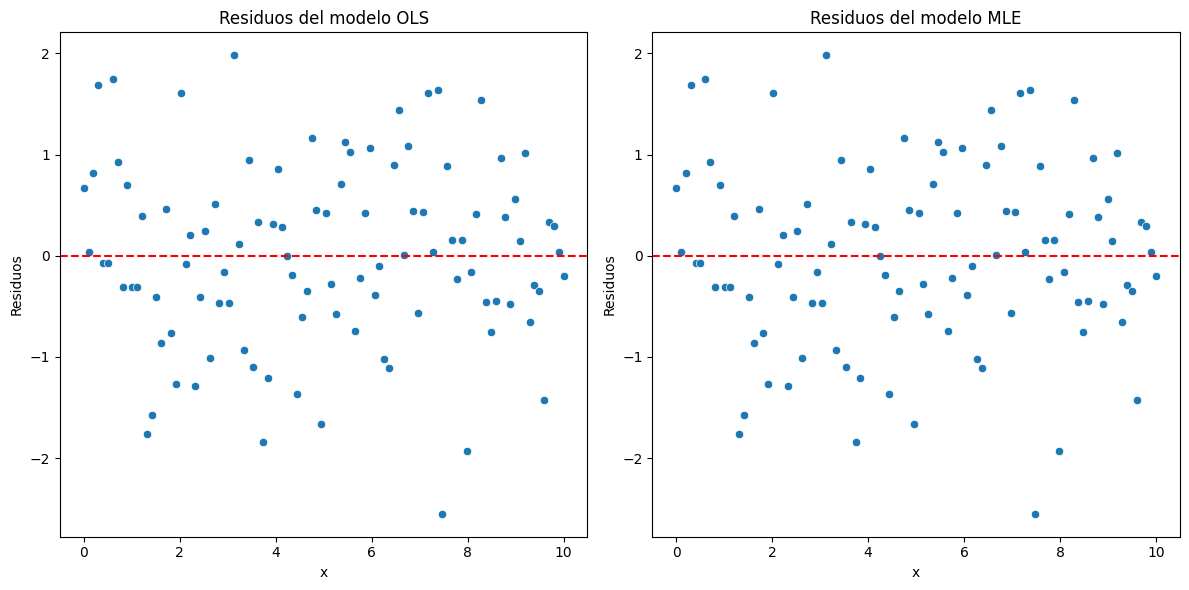

In [ ]:
# Calcular residuos para OLS
ols_residuals = y - ols_model.predict(X)

# Calcular residuos para MLE
mle_residuals = y - (b0_mle + b1_mle * x)

# Visualizar residuos
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=x, y=ols_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuos del modelo OLS')
plt.xlabel('x')
plt.ylabel('Residuos')

plt.subplot(1, 2, 2)
sns.scatterplot(x=x, y=mle_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuos del modelo MLE')
plt.xlabel('x')
plt.ylabel('Residuos')

plt.tight_layout()
plt.show()


---

### 📐 Estimación por Mínimos Cuadrados (OLS)

Sea el modelo:

$
y_i = \beta_0 + \beta_1 x_i + \varepsilon_i, \quad \varepsilon_i \sim \mathcal{N}(0, \sigma^2)
$

El objetivo es minimizar:

$
S(\beta_0, \beta_1) = \sum_{i=1}^{n} (y_i - \beta_0 - \beta_1 x_i)^2
$

Soluciones analíticas:

$
\hat{\beta}_1 = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}, \quad
\hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}
$

Varianza residual:

$
\hat{\sigma}^2 = \frac{1}{n - 2} \sum (y_i - \hat{y}_i)^2
$


---

### 📊 Estimación por Máxima Verosimilitud (MLE)

Modelo con errores normales:

$
y_i = \beta_0 + \beta_1 x_i + \varepsilon_i, \quad \varepsilon_i \sim \mathcal{N}(0, \sigma^2)
$

Función de verosimilitud:

$
L(\beta_0, \beta_1, \sigma^2) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{(y_i - \beta_0 - \beta_1 x_i)^2}{2\sigma^2} \right)
$

Log-verosimilitud:

$
\ell(\beta_0, \beta_1, \sigma^2) = -\frac{n}{2} \log(2\pi) - \frac{n}{2} \log(\sigma^2) - \frac{1}{2\sigma^2} \sum (y_i - \beta_0 - \beta_1 x_i)^2
$

El estimador MLE de $\sigma^2$ difiere del de OLS:

$
\hat{\sigma}^2_{MLE} = \frac{1}{n} \sum (y_i - \hat{y}_i)^2
$


---







## 🧪 Código Python para estimación OLS y MLE


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import statsmodels.api as sm

# Simular datos
np.random.seed(42)
n = 100
x = np.linspace(0, 10, n)
beta_0, beta_1, sigma = 2, 3, 1
y = beta_0 + beta_1 * x + np.random.normal(0, sigma, n)

In [ ]:
# OLS con statsmodels
X = sm.add_constant(x)
ols_model = sm.OLS(y, X).fit()
print("OLS summary:")
print(ols_model.summary())

OLS summary:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                     9286.
Date:                Tue, 11 Nov 2025   Prob (F-statistic):           6.75e-99
Time:                        02:29:22   Log-Likelihood:                -131.66
No. Observations:                 100   AIC:                             267.3
Df Residuals:                      98   BIC:                             272.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.8272      0.181     10

In [ ]:

# MLE: función de log-verosimilitud negativa
def neg_log_likelihood(params):
    b0, b1, sigma = params
    y_pred = b0 + b1 * x
    ll = -0.5 * np.sum(np.log(2 * np.pi * sigma**2) + ((y - y_pred)**2) / sigma**2)
    return -ll

# Estimación MLE
init_params = [0, 0, 1]
result = minimize(neg_log_likelihood, init_params, method='Nelder-Mead')
b0_mle, b1_mle, sigma_mle = result.x

print(f"\nMLE estimates:\nβ₀ = {b0_mle:.3f}, β₁ = {b1_mle:.3f}, σ = {sigma_mle:.3f}")


MLE estimates:
β₀ = 1.827, β₁ = 3.014, σ = 0.903
